In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc

unsharpened_maps_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/data/unsharpened_maps"
confidence_masks_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/data/confidence_masks"
emmernet_predictions_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/outputs/feature_enhance_test_maps_hybrid_60k"
emmernet_predictions_full_network = "/home/abharadwaj1/papers/elife_paper/figure_information/outputs/emmernet_test_hybrid_model_map_60k_dataset"
emdb_pdbs = [x for x in os.listdir(emmernet_predictions_folder)]


In [2]:
input_files_emdb = {}
for emdb_pdb in emdb_pdbs:
    emdb, pdb = emdb_pdb.split('_')
    
    emdb_prediction_folder = os.path.join(emmernet_predictions_folder, emdb_pdb)
    mean_prediction_path = os.path.join(emdb_prediction_folder, f"emd_{emdb}_emmernet_output_mean.mrc")
    full_network_prediction_path = os.path.join(emmernet_predictions_full_network, emdb_pdb, f"emd_{emdb}_emmernet_output.mrc")
    var_prediction_path = os.path.join(emdb_prediction_folder, f"emd_{emdb}_emmernet_output_var.mrc")
    unsharpened_map_path = os.path.join(emdb_prediction_folder, f"EMD_{int(emdb)}_unsharpened_fullmap.mrc")
    mask_path = os.path.join(confidence_masks_folder, f"emd_{emdb}_FDR_confidence_final.map")
    locscale_map_path = os.path.join(emdb_prediction_folder, f"emd_{emdb}_emmernet_output_locscale_output.mrc")
    
    temp_dict = {
        "mean_prediction_path": mean_prediction_path,
        "var_prediction_path": var_prediction_path,
        "unsharpened_map_path": unsharpened_map_path,
        "mask_path": mask_path,
        "locscale_map_path": locscale_map_path,
        "full_network_prediction_path": full_network_prediction_path
    }
    
    # assert all paths exist
    all_paths_exist = True 
    for k, v in temp_dict.items():
        all_paths_exist = all_paths_exist and os.path.exists(v)
    
    if all_paths_exist:
        input_files_emdb[emdb_pdb] = temp_dict
    else:
        # print which paths do not exist
        missing_paths = {}
        
        for k, v in temp_dict.items():
            if not os.path.exists(v):
                missing_paths[k] = v
        print(f"Missing paths for {emdb_pdb}: {missing_paths}")


In [9]:
from locscale.emmernet.emmernet_functions import load_smoothened_mask

residuals_emdb = {}
squared_residuals_emdb = {}
residuals_locscale_emdb = {}
squared_residuals_locscale_emdb = {}
residuals_percentage_emdb = {}
residuals_mean_and_full_map = {}
variance_emdb = {}
for emdb_pdb in input_files_emdb.keys():
    mean_prediction_path = input_files_emdb[emdb_pdb]['mean_prediction_path']
    full_network_prediction_path = input_files_emdb[emdb_pdb]['full_network_prediction_path']
    locscale_map_path = input_files_emdb[emdb_pdb]['locscale_map_path']
    mask_path = input_files_emdb[emdb_pdb]['mask_path']
    var_prediction_path = input_files_emdb[emdb_pdb]['var_prediction_path']
    
    mean_prediction, apix = load_map(mean_prediction_path)
    full_network_prediction, _ = load_map(full_network_prediction_path)
    mask, _ = load_smoothened_mask(mask_path, mask_threshold=0.99)
    locscale_map, _ = load_map(locscale_map_path)
    var_prediction, _ = load_map(var_prediction_path)
    
    mask_binary = mask > 0.5
    mean_prediction_masked = mean_prediction[mask_binary]
    full_network_prediction_masked = full_network_prediction[mask_binary]
    locscale_map_masked = locscale_map[mask_binary]
    var_prediction_masked = var_prediction[mask_binary]
    
    residuals_full_map = mean_prediction_masked - full_network_prediction_masked
    residuals_locscale = locscale_map_masked - mean_prediction_masked
    
    residuals_mean_and_full_map[emdb_pdb] = residuals_full_map
    residuals_locscale_emdb[emdb_pdb] = residuals_locscale
    squared_residuals_locscale_emdb[emdb_pdb] = residuals_locscale**2
    variance_emdb[emdb_pdb] = var_prediction_masked


Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3
Mask threshold: 0.99
Cosine filter: 3


6312084
6312084
(6312084,)
(6312084,)


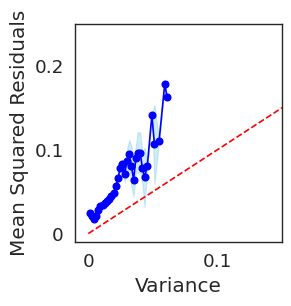

Uncertainty Calibration Error (UCE): 0.01845545485082797
Maximum Calibration Error (MCE): 0.01845545485082797
Unweighted Calibration Error: 0.043139964


([array([0.0003179 , 0.00027936, 0.00031015, ..., 0.00074754, 0.00082775,
         0.00083663], dtype=float32),
  array([0.00183954, 0.00182267, 0.00182882, ..., 0.00233721, 0.00185283,
         0.00195023], dtype=float32),
  array([0.00378113, 0.00459342, 0.00403683, ..., 0.00371743, 0.00373581,
         0.00366701], dtype=float32),
  array([0.00527037, 0.00544212, 0.00558653, ..., 0.00531093, 0.00569801,
         0.00527423], dtype=float32),
  array([0.0078725 , 0.00767937, 0.00713656, ..., 0.00728378, 0.00735525,
         0.00774238], dtype=float32),
  array([0.00873523, 0.00880816, 0.00891711, ..., 0.00920426, 0.00882047,
         0.00888201], dtype=float32),
  array([0.01037108, 0.01069664, 0.01100669, ..., 0.01063974, 0.01080247,
         0.01084561], dtype=float32),
  array([0.01207628, 0.01244331, 0.01248671, ..., 0.01317164, 0.0122181 ,
         0.012147  ], dtype=float32),
  array([0.01418249, 0.01498665, 0.0139629 , ..., 0.013947  , 0.01423111,
         0.01432009], dtype=fl

In [21]:
# plotting
x_array_list = list(variance_emdb.values())
y_array_list = list(residuals_locscale_emdb.values())
x_array = np.concatenate([x for x in x_array_list])
y_array = np.concatenate([y for y in y_array_list])
x_array = np.sqrt(x_array) / np.sqrt(15)
y_array = np.abs(y_array)
print(len(x_array))
print(len(y_array))
print(x_array.shape)
print(y_array.shape)
plot_binned_residuals(x_array, y_array)

In [ ]:
from scipy.stats import probplot

residuals_combined = []
for emdb in input_files_emdb:
    residuals_to_plot = residuals_locscale_emdb[emdb]
    residuals_sample = np.random.choice(residuals_to_plot, 1000, replace=False)
    residuals_combined.extend(residuals_sample)

residuals_combined = np.array(residuals_combined)

fig, ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(residuals_combined, ax=ax[0], kde=True)
probplot(residuals_combined, plot=ax[1]);
print("Mean Absolute Residual: {}".format(np.mean(np.abs(residuals_combined))))

plt.tight_layout()

In [ ]:
from scipy.stats import skew, kurtosis

skewness = skew(residuals_combined)
kurtosis_residues = kurtosis(residuals_combined)

print("Skewness: {}".format(skewness))
print("Kurtosis: {}".format(kurtosis_residues))

In [ ]:
from locscale.emmernet.emmernet_functions import load_smoothened_mask

zscore_emdb = {}
variances_emdb = {}
variances_thresholded_mask_emdb = {}
for emdb_pdb in input_files_emdb.keys():
    mean_prediction_path = input_files_emdb[emdb_pdb]['mean_prediction_path']
    full_network_prediction_path = input_files_emdb[emdb_pdb]['full_network_prediction_path']
    var_prediction_path = input_files_emdb[emdb_pdb]['var_prediction_path']
    mask_path = input_files_emdb[emdb_pdb]['mask_path']
    locscale_map_path = input_files_emdb[emdb_pdb]['locscale_map_path']
    
    mean_prediction, apix = load_map(mean_prediction_path)
    full_network_prediction, _ = load_map(full_network_prediction_path)
    variance_prediction, _ = load_map(var_prediction_path)
    mask, _ = load_smoothened_mask(mask_path)
    mean_prediction_thresholded_mask = (mean_prediction >= 0.1)
    
    locscale_map, _ = load_map(locscale_map_path)
    
    mask_binary = mask > 0.5
    mean_prediction_masked = mean_prediction[mask_binary]
    full_network_prediction_masked = full_network_prediction[mask_binary]
    variance_prediction_masked = variance_prediction[mask_binary]
    variance_thresholded_masked = variance_prediction[mean_prediction_thresholded_mask]
    locscale_map_masked = locscale_map[mask_binary]
    
    standard_deviation_prediction_masked = np.sqrt(variance_prediction_masked)
    standard_error_prediction_masked = standard_deviation_prediction_masked / np.sqrt(15)
    z_score = (locscale_map_masked - mean_prediction_masked) / standard_error_prediction_masked
    
    variances_emdb[emdb_pdb] = variance_prediction_masked
    variances_thresholded_mask_emdb[emdb_pdb] = variance_thresholded_masked
    zscore_emdb[emdb_pdb] = z_score

In [ ]:
# plot the distribution of variances_thresholded_mask_emdb
variances_within_thresholded_mask = []
for emdb_pdb in variances_thresholded_mask_emdb.keys():
    variances_within_thresholded_mask.extend(variances_thresholded_mask_emdb[emdb_pdb])

# plot the sample of variances_within_thresholded_mask
variances_within_thresholded_mask_sample = np.random.choice(variances_within_thresholded_mask, 1000, replace=False)
fig, ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(variances_within_thresholded_mask_sample, ax=ax[0], kde=True)
probplot(variances_within_thresholded_mask_sample, plot=ax[1]);
# set title
plt.suptitle("Distribution of variances within the thresholded mask")
print("Min variance: {}".format(np.min(variances_within_thresholded_mask)))
print("1st percentile variance: {}".format(np.percentile(variances_within_thresholded_mask, 1)))
print("5th percentile variance: {}".format(np.percentile(variances_within_thresholded_mask, 5)))
print("10th percentile variance: {}".format(np.percentile(variances_within_thresholded_mask, 10)))
print("Max variance: {}".format(np.max(variances_within_thresholded_mask)))
print("Mean variance: {}".format(np.mean(variances_within_thresholded_mask)))
print("Median variance: {}".format(np.median(variances_within_thresholded_mask)))


In [ ]:
target_emdb = np.random.choice(list(input_files_emdb.keys()),1)[0]
zscores_to_plot = zscore_emdb[target_emdb]
zscores_sample = np.random.choice(zscores_to_plot, 1000, replace=False)
print("Target emdb: {}".format(target_emdb))
fig, ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(zscores_sample, ax=ax[0], kde=True)
probplot(zscores_sample, plot=ax[1]);

plt.tight_layout()

In [ ]:
zscores_all = []
for zscores in zscore_emdb.values():
    zscores_all.extend(zscores)
zscores_all = np.array(zscores_all)

z_scores_sample = np.random.choice(zscores_all, size=1000)

# Plot the histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(z_scores_sample, ax=ax[0])
ax[0].set_xlabel('Z-score')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Z-scores')

# Plot the QQ plot
probplot(z_scores_sample, plot=ax[1])
ax[1].set_xlabel('Theoretical quantiles')
ax[1].set_ylabel('Ordered values')
ax[1].set_title('QQ plot of Z-scores')




In [ ]:
# print number of positive zscores_all and residuals_all
print('Number of positive zscores_all: ', len(zscores_all[zscores_all > 0]))
print('Number of negative zscores_all: ', len(zscores_all[zscores_all < 0]))
print('Number of positive residuals_all: ', len(residuals_combined[residuals_combined > 0]))
print('Number of negative residuals_all: ', len(residuals_combined[residuals_combined < 0]))


In [ ]:
variances_combined = []
residuals_combined_full = []
squared_residuals_full = []
for emd in input_files_emdb:
    variances_combined.extend(variances_emdb[emd])
    residuals_combined_full.extend(residuals_locscale_emdb[emd])
    squared_residuals_full.extend(squared_residuals_locscale_emdb[emd])

sampled_indices = np.random.choice(len(variances_combined), size=50000, replace=False)
variances_combined_sampled = [variances_combined[i] for i in sampled_indices]
residuals_combined_sampled = [residuals_combined_full[i] for i in sampled_indices]
squared_residuals_sampled = [squared_residuals_full[i] for i in sampled_indices]

pearson_score = pearsonr(variances_combined_sampled, residuals_combined_sampled)
print("Pearson score: {}".format(pearson_score))
plt.scatter(variances_combined_sampled, residuals_combined_sampled, alpha=0.5)
plt.xlabel("Variance")
plt.ylabel("Residual")
plt.show()

In [ ]:
# print positive residuals_combined_full and positive z-scores 
residuals_combined_full = np.array(residuals_combined_full)
print("positive residuals_combined_full", len(residuals_combined_full[residuals_combined_full > 0]))
print("positive z-scores", len(zscores_all[zscores_all > 0]))


In [ ]:
pearson_score = pearsonr(variances_combined_sampled, squared_residuals_sampled)
print("Pearson score: {}".format(pearson_score))
plt.scatter(variances_combined_sampled, squared_residuals_sampled, alpha=0.5)
plt.xlabel("Variance")
plt.ylabel("MSE")
plt.show()

In [ ]:
def find_optimal_scale_factor(x, y):
    """Find the optimal scale factor for the given data.
    
    Parameters
    ----------
    x : array_like
        The x data.
    y : array_like
        The y data.
    
    Returns
    -------
    float
        The optimal scale factor.
        y = scale_factor * x
    """
    # Compute the scale factor
    from scipy.optimize import curve_fit
    def func(x, a):
        return a * x
    popt, pcov = curve_fit(func, x, y)
    scale_factor = popt[0]
    return scale_factor

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_binned_residuals(variances_combined_sampled, squared_residuals_sampled, \
                        num_bins=50, xlabel='Variance', ylabel='Mean Squared Residuals', title='Mean Squared Residuals by Variance Bin',\
                        save_path=None, figsize_cm=(8, 8), font='Helvetica', fontscale=1.5, linewidth=2, marker='o', markersize=10):
    """
    Plot the binned squared residuals as a function of variance.

    Parameters:
    - variances_combined_sampled: numpy array of variances.
    - squared_residuals_sampled: numpy array of squared residuals.
    - num_bins: number of bins for the x-axis (default is 50).
    """
    import matplotlib.pyplot as plt
    from matplotlib.pyplot import cm
    import seaborn as sns    
    from matplotlib.pyplot import cm
    import matplotlib as mpl
    ## Function not generic
    mpl.rcParams['pdf.fonttype'] = 42
    figsize = (figsize_cm[0] / 2.54, figsize_cm[1] / 2.54)
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(context="paper", font=font, font_scale=fontscale)
    sns.set_style("white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel, rotation=90, ha="center")
    import warnings
    warnings.filterwarnings('ignore')
    variances_combined_sampled = np.array(variances_combined_sampled)
    squared_residuals_sampled = np.array(squared_residuals_sampled)
    # Binning the variances_combined_sampled data
    bins = np.linspace(variances_combined_sampled.min(), variances_combined_sampled.max(), num_bins + 1)
    bin_indices = np.digitize(variances_combined_sampled, bins)

    # Compute the statistics for each bin
    bin_weight_threshold = 1e-9
    bin_not_empty = lambda i: len(variances_combined_sampled[bin_indices == i]) > 0
    bin_weight_check = lambda i: True#len(variances_combined_sampled[bin_indices == i]) / len(variances_combined_sampled) > bin_weight_threshold
    weight_per_bin = [len(variances_combined_sampled[bin_indices == i]) / len(variances_combined_sampled) for i in range(1, len(bins)) if bin_not_empty(i)]
    uncertainty_bin_means = [variances_combined_sampled[bin_indices == i].mean() for i in range(1, len(bins)) if bin_not_empty(i) and bin_weight_check(i)]
    residual_means = [squared_residuals_sampled[bin_indices == i].mean() for i in range(1, len(bins)) if bin_not_empty(i) and bin_weight_check(i)]
    residual_stds = [squared_residuals_sampled[bin_indices == i].std() for i in range(1, len(bins)) if bin_not_empty(i) and bin_weight_check(i)]
    #residual_standard_errors = [squared_residuals_sampled[bin_indices == i].std() / np.sqrt(len(squared_residuals_sampled[bin_indices == i])) for i in range(1, len(bins))]
    confidence_interval = 95
    z_score = 1.96
    residual_standard_errors = [z_score * squared_residuals_sampled[bin_indices == i].std() / np.sqrt(len(squared_residuals_sampled[bin_indices == i])) for i in range(1, len(bins)) if bin_not_empty(i) and bin_weight_check(i)]
    
    uncertainty_bin_values = [variances_combined_sampled[bin_indices == i] for i in range(1, len(bins)) if bin_not_empty(i) and bin_weight_check(i)]
    residual_bin_values = [squared_residuals_sampled[bin_indices == i] for i in range(1, len(bins)) if bin_not_empty(i) and bin_weight_check(i)]
    

    ax.plot(uncertainty_bin_means, residual_means, color='blue', marker='o')
    # plot diagonal line for reference
    ax.plot([0, 1], [0, 1], color='red', linestyle='--')
    ax.fill_between(uncertainty_bin_means, np.array(residual_means) - np.array(residual_standard_errors), np.array(residual_means) + np.array(residual_standard_errors), color='skyblue', alpha=0.4, label='1 Standard Deviation')
    
    residues_max = np.max(residual_means)
    uncertainty_max = np.max(uncertainty_bin_means)
    ymax = np.max([residues_max, uncertainty_max])
    ax.set_xlim(-0.01, 0.15)
    ax.set_ylim(-0.01, 0.25)
    xticks = [0, 0.1]
    yticks = [0, 0.1, 0.2]
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels(xticks)
    ax.set_yticklabels(yticks)
    
    plt.tight_layout()
    plt.show()
    
    # compute the Uncertainty Calibration Error (UCE) and Expected Calibration Error (ECE)
    uce = 0
    mce = 0
    total_number_of_elements = len(squared_residuals_sampled)
    for i in range(len(uncertainty_bin_means)):
        number_of_elements_in_bin = len(squared_residuals_sampled[bin_indices == i + 1])
        absolute_calibration_error = np.abs(residual_means[i] - uncertainty_bin_means[i])
        maximum_calibration_error = np.max([residual_means[i] - uncertainty_bin_means[i]])
        if np.isnan(absolute_calibration_error):
            absolute_calibration_error = 0
        uncertainty_calibration_error = absolute_calibration_error * number_of_elements_in_bin / total_number_of_elements
        maximum_uncertainty_calibration_error = maximum_calibration_error * number_of_elements_in_bin / total_number_of_elements
        
        uce += uncertainty_calibration_error
        mce += maximum_uncertainty_calibration_error
    
    
    print('Uncertainty Calibration Error (UCE):', uce)
    print('Maximum Calibration Error (MCE):', mce)

    # calculate unweighted calibration error
    unweighted_calibration_error = np.mean(np.abs(np.array(residual_means) - np.array(uncertainty_bin_means)))
    print('Unweighted Calibration Error:', unweighted_calibration_error)
    
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
    
    return uncertainty_bin_values, residual_bin_values

In [ ]:
standard_errors_full = np.sqrt(variances_combined) / np.sqrt(15)
uncertainty_bin_values, residual_bin_values = plot_binned_residuals(standard_errors_full, abs(residuals_combined_full), num_bins=64, 
                                                                    xlabel="Standard Error", ylabel="Mean Absolute Residual",\
                                                                    save_path=None)

In [ ]:
# remove all variance values, and residuals belonging to noise voxels 
# (i.e. voxels with variance below a certain threshold)

variance_threshold = 0.0002
variances_combined = np.array(variances_combined)
noise_voxels = (variances_combined < variance_threshold)
standard_errors_signal = standard_errors_full[~noise_voxels]
residuals_combined_full = np.array(residuals_combined_full)
residuals_combined_signal = residuals_combined_full[~noise_voxels]

uncertainty_bin_values, residual_bin_values = plot_binned_residuals(standard_errors_signal, abs(residuals_combined_signal), num_bins=64, 
                                                                    xlabel="Standard Error", ylabel="Mean Absolute Residual",\
                                                                    )


In [ ]:
# use sklearn isotonic regression to calibrate the variances 
from sklearn.isotonic import IsotonicRegression

iso_reg = IsotonicRegression(out_of_bounds='clip')

X = np.array(standard_errors_full)
Y = np.abs(residuals_combined_full)
Y[noise_voxels] = 0 

shuffle_indices = np.random.permutation(len(X))
X_shuffled = X[shuffle_indices]
Y_shuffled = Y[shuffle_indices]

split_index = int(len(X_shuffled) * 0.6)
X_train = X_shuffled[:split_index]
Y_train = Y_shuffled[:split_index]

X_test_raw = X_shuffled[split_index:]
Y_test_raw = Y_shuffled[split_index:]
noise_test_voxels = (X_test_raw < standard_errors_signal.min())
X_test = X_test_raw[~noise_test_voxels]
Y_test = Y_test_raw[~noise_test_voxels]


iso_reg.fit(X_train, Y_train)

Y_pred = iso_reg.predict(X_test)

In [ ]:
plot_binned_residuals(Y_pred, Y_test, num_bins=64, \
                    xlabel="Standard Error", ylabel="Mean Absolute Residual",\
                    );


In [ ]:
noise_voxels_train = (X_train < standard_errors_signal.min()) 
X_train_plot = X_train[~noise_voxels_train]
Y_train_plot = Y_train[~noise_voxels_train]
Y_train_pred = iso_reg.predict(X_train_plot)
plot_binned_residuals(Y_train_pred, Y_train_plot, num_bins=128);


In [ ]:
def pretty_lineplot_XY(xdata, ydata, xlabel, ylabel, figsize=(14,8), \
                        marker="o", markersize=12,fontscale=2.5,font="Helvetica", \
                        linewidth=2,legends=None):
    import matplotlib.pyplot as plt
    from matplotlib.pyplot import cm
    import seaborn as sns    
    from matplotlib.pyplot import cm
    import matplotlib as mpl
    ## Function not generic
    mpl.rcParams['pdf.fonttype'] = 42
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(context="paper", font=font, font_scale=fontscale)
    sns.set_style("white")
    sns.lineplot(x=xdata,y=ydata,linewidth=linewidth,ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel, rotation=90, ha="center")

    if legends is not None:        
        ax.legend(legends)
    plt.tight_layout()

    return fig

In [ ]:
x_array = np.linspace(-0.005, 0.07, 1000)
y_preds = iso_reg.predict(x_array)
fig = pretty_lineplot_XY(x_array, y_preds, \
                        xlabel="Uncalibrated SE", ylabel="Calibrated SE", \
                        figsize=(4, 4), )
#fig.savefig("calibration_curve.eps", dpi=600, bbox_inches="tight")


In [ ]:
test_variance = 0.0002
test_standard_error = np.sqrt(test_variance) / np.sqrt(15)
new_standard_error = iso_reg.predict([test_standard_error])
print("Old standard error: {}".format(test_standard_error))
print("New standard error: {}".format(new_standard_error))


In [ ]:
# import pickle
# # save the iso_reg model
# with open('calibrator_locscale_target.pkl', 'wb') as f:
#     pickle.dump(iso_reg, f)
    

In [ ]:
from scipy.stats import pearsonr

r_value = pearsonr(Y_test, X_test)
print("Pearson's r: ", r_value[0])

In [ ]:
plt.scatter(Y_pred, Y_test, s=1, alpha=0.1)
plt.xlim(-0.01, 0.06)
plt.ylim(-0.01, 0.2)

In [ ]:
absolute_residuals_sampled = np.random.choice((residuals_combined_full), size=1000, replace=False)
sns.histplot((absolute_residuals_sampled), bins=100, kde=True)

In [ ]:
squared_residuals_combined_sampled = np.square(residuals_combined_sampled)
sns.histplot(np.log(squared_residuals_combined_sampled), bins=100, kde=True)

In [ ]:
# # fit a skew normal distribution to the log normal of squared residuals

# from scipy.stats import skewnorm, probplot
# import numpy as np

# data = np.log(squared_residuals_combined_sampled)
# params = skewnorm.fit(data)
# print(params)
# probplot(data, dist="skewnorm", sparams=params, plot=plt);

In [ ]:
# # fit a gamma distribution
# from scipy.stats import gamma
# data = np.log(squared_residuals_combined_sampled)
# params = gamma.fit(data)
# print(params)
# print("Length of data: ", len(data))
# # sample 1000 points from the fitted distribution
# sampled_data = np.random.choice(data, 1000)
# probplot(sampled_data, dist="gamma", sparams=params, plot=plt);

In [ ]:
# import  pickle

# data = {
#     "variance" : variances_combined_sampled,
#     "residuals" : residuals_combined_sampled,
# }

# #pickle.dump(data, open("residuals_and_variances.pickle", "wb"))

In [ ]:
def plot_binned_correlation(xarray, yarray, num_bins=50, ci = 0.95, figsize_cm=(8, 8)):
    import matplotlib.pyplot as plt
    import seaborn as sns    
    import scipy.stats as st
    import numpy as np
    
    sns.set_style("white")
            
    figsize = (figsize_cm[0] / 2.54, figsize_cm[1] / 2.54)
    fig, ax = plt.subplots(figsize=figsize)

    import warnings
    warnings.filterwarnings('ignore')
    xarray = np.array(xarray)
    yarray = np.array(yarray)
    
    # Binning by the x axis data
    bins = np.linspace(xarray.min(), xarray.max(), num_bins)
    bin_indices = np.digitize(xarray, bins)

    # Compute the statistics for each bin
    bin_not_empty = lambda i: len(xarray[bin_indices == i]) > 0
    
    xarray_bin_means = [xarray[bin_indices == i].mean() for i in range(len(bins)) if bin_not_empty(i)]
    yarray_bin_means = [yarray[bin_indices == i].mean() for i in range(len(bins)) if bin_not_empty(i)]
    yarray_bin_stds = [yarray[bin_indices == i].std() for i in range(len(bins)) if bin_not_empty(i)]
    yarray_bin_nums = [len(yarray[bin_indices == i]) for i in range(len(bins)) if bin_not_empty(i)]
    z_score = st.norm.ppf(ci)
    yarray_standard_errors = [z_score * yarray_bin_stds[i] / np.sqrt(yarray_bin_nums[i]) for i in range(len(xarray_bin_means))]
    
    # convert to numpy arrays
    xarray_bin_means = np.array(xarray_bin_means)
    yarray_bin_means = np.array(yarray_bin_means)
    yarray_standard_errors = np.array(yarray_standard_errors)
    
    # Find max yarray and min yarray
    yarray_top = yarray_bin_means + yarray_standard_errors
    yarray_bottom = yarray_bin_means - yarray_standard_errors
        
    ax.plot(xarray_bin_means, yarray_bin_means, color='blue', marker='o')
    # plot diagonal line for reference
    max_x, max_y = np.max(xarray_bin_means), np.max(yarray_bin_means)
    min_x, min_y = np.min(xarray_bin_means), np.min(yarray_bin_means)
    min_val, max_val = np.min([min_x, min_y]), np.max([max_x, max_y])
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    # shade the area between the standard errors
    ax.fill_between(xarray_bin_means, yarray_bottom, yarray_top, color='skyblue', alpha=0.4, label=f'ci:{ci}')
    
    plt.tight_layout()
    
    return fig, ax

In [ ]:
def compute_reliability_curve(locscale_path, mean_prediction_path, variance_prediction_path, n_samples=15):
    from locscale.emmernet.utils import load_calibrator
    from locscale.include.emmer.ndimage.map_utils import load_map
    import numpy as np
    import os     
    
    locscale_map, apix = load_map(locscale_path)
    mean_prediction, _ = load_map(mean_prediction_path)
    variance_prediction, _ = load_map(variance_prediction_path)
    
    variance_mask = variance_prediction > 0.0002
    
    locscale_masked = locscale_map[variance_mask]
    mean_masked = mean_prediction[variance_mask]
    variance_masked = variance_prediction[variance_mask]
    
    standard_deviation_masked = np.sqrt(variance_masked)
    standard_error_masked = standard_deviation_masked / np.sqrt(n_samples)
    
    calibrator = load_calibrator()
    calibrated_standard_error = calibrator.predict(standard_error_masked)
    
    absolute_residual = np.abs(locscale_masked - mean_masked)
    
    fig, ax = plot_binned_correlation(calibrated_standard_error, absolute_residual, num_bins=128, ci=0.95, figsize_cm=(8, 8))
    # modify plot 
    ax.set_xlabel("Calibrated Standard Error")
    ax.set_ylabel("Absolute Residual")
    ax.set_title("Reliability Curve")
    
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    maxval, minval = np.max([xmax, ymax]), np.min([xmin, ymin])
    
    ax.set_xlim(minval, maxval)
    ax.set_ylim(minval, maxval)
    
    return fig, ax 
    
test_map_folder = "/home/abharadwaj1/dev/dirty_tests/calibrate_variance"
locscale_path = os.path.join(test_map_folder, "emd_3061_calibrated_SE_probabilities_locscale_output.mrc")    
variance_path = os.path.join(test_map_folder, "emd_3061_calibrated_SE_probabilities_var.mrc")
mean_path = os.path.join(test_map_folder, "emd_3061_calibrated_SE_probabilities_mean.mrc")

fig, ax  = compute_reliability_curve(locscale_path, mean_path, variance_path, n_samples=15)

    
    

In [ ]:
def compute_calibrated_probabilities(locscale_path, mean_prediction_path, variance_prediction_path, n_samples=15, calibrate=True):
    from locscale.emmernet.utils import load_calibrator
    from locscale.include.emmer.ndimage.map_utils import load_map
    import numpy as np
    import os 
    
    #http://www.ltcconline.net/greenl/courses/201/estimation/smallConfLevelTable.htm
    z_target_for_each_CI = {70 : 1.04, 80: 1.28, 90: 1.645, 95: 1.96, 99: 2.58}
    
    
    locscale_map, apix = load_map(locscale_path)
    mean_prediction, _ = load_map(mean_prediction_path)
    variance_prediction, _ = load_map(variance_prediction_path)
    
    variance_mask = variance_prediction > 0.0002
    
    locscale_masked = locscale_map[variance_mask]
    mean_masked = mean_prediction[variance_mask]
    variance_masked = variance_prediction[variance_mask]
    
    standard_deviation_masked = np.sqrt(variance_masked)
    standard_error_masked = standard_deviation_masked / np.sqrt(n_samples)
    
    calibrator = load_calibrator()
    if calibrate:
        calibrated_standard_error = calibrator.predict(standard_error_masked)
    else:
        calibrated_standard_error = standard_error_masked
    
    # compute the z-scores
    z_scores = (locscale_masked - mean_masked) / calibrated_standard_error
    
    # compute the probabilities for different confidence intervals
    observed_probabilities = {}
    for ci in z_target_for_each_CI:
        z_target = z_target_for_each_CI[ci]
        observed_probability = np.sum(np.abs(z_scores) < z_target)
        observed_probabilities[ci] = observed_probability / len(z_scores)
        
    
    return observed_probabilities

import os 
from locscale.utils.general import try_to

test_map_folder = "/home/abharadwaj1/dev/dirty_tests/high_context"
locscale_path = os.path.join(test_map_folder, "emd_3061_high_context_locscale_output.mrc")    
variance_path = os.path.join(test_map_folder, "emd_3061_high_context_var.mrc")
mean_path = os.path.join(test_map_folder, "emd_3061_high_context_mean.mrc")

prob_args = {"locscale_path" : locscale_path, "mean_prediction_path" : mean_path, "variance_prediction_path" : variance_path, "n_samples" : 15, "calibrate" : True}

observed_probabilities = try_to(compute_calibrated_probabilities, **prob_args)

print("Expected and observed probabilities for different confidence intervals")
for ci in observed_probabilities:
    print("Expected Probability: {:.2f}, Observed Probability: {:.2f}".format(ci, 100*observed_probabilities[ci]))

# dump the observed probabilities to a json file
import json
json_file_path = os.path.join(test_map_folder, "observed_probabilities.json")
with open(json_file_path, 'w') as f:
    json.dump(observed_probabilities, f, indent=4)    
    

In [ ]:

test_map_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/outputs/running_model_free_multiple"
locscale_path = os.path.join(test_map_folder, "final_locscale.mrc")    
variance_path = os.path.join(test_map_folder, "var_model_map.mrc")
mean_path = os.path.join(test_map_folder, "mean_model_map.mrc")

observed_probabilities = compute_calibrated_probabilities(locscale_path, mean_path, variance_path, n_samples=25, calibrate=False)

print("Expected and observed probabilities for different confidence intervals")
for ci in observed_probabilities:
    print("Expected Probability: {:.2f}, Observed Probability: {:.2f}".format(ci, 100*observed_probabilities[ci]))
    

In [ ]:
def calculate_significance_map_from_emmernet_output(locscale_output_path, mean_prediction_path, var_prediction_path, n_samples=15):
    from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
    from locscale.emmernet.emmernet_functions import calibrate_variance
    from scipy.stats import norm
    import os
    import warnings
    import numpy as np
    # filter out warnings
    warnings.filterwarnings("ignore")
    # compute the z score map 
    locscale_map, apix = load_map(locscale_output_path)
    mean_prediction, apix = load_map(mean_prediction_path)
    var_prediction, apix = load_map(var_prediction_path)

    standard_deviation = np.sqrt(var_prediction)
    standard_error = standard_deviation / np.sqrt(n_samples)

    z_score_map = (locscale_map - mean_prediction) / standard_error

    # convert nan values to 1
    z_score_map[np.isnan(z_score_map)] = 0
    # convert the z score map to a p value map

    cdf_map = norm.cdf(z_score_map)
    # renormalize to -100 and 100
    probabilities_map = cdf_map * 200 - 100
    
    
    output_folder = os.path.dirname(locscale_output_path)

    p_value_map_path = os.path.join(output_folder, "hallucinations_probabilities_map.mrc")
    z_score_map_path = os.path.join(output_folder, "z_scores_calibrated.mrc")

    save_as_mrc(probabilities_map, p_value_map_path, apix)
    save_as_mrc(z_score_map, z_score_map_path, apix)


In [ ]:

calculate_significance_map_from_emmernet_output(locscale_path, mean_path, variance_path, n_samples=25)

In [ ]:
from locscale.emmernet.emmernet_functions import load_smoothened_mask
fraction_of_voxels_containing_target_emdb = {}
num_correct_captures = 0
num_total_voxels = 0
scaling_factor = 8
credible_interval_tests = [80, 90, 95, 99]
observed_proportion_for_each_CI = {}
num_correct_captures_for_each_CI = {80: 0, 90: 0, 95: 0, 99: 0}
num_total_voxels_for_each_CI = {80: 0, 90: 0, 95: 0, 99: 0}
z_target_for_each_CI = {80: 1.2816, 90: 1.6449, 95: 1.96, 99: 2.5758}
t_statistic_multiplier_for_each_CI = {80: 1.345, 90: 1.761, 95: 2.145, 99: 2.977}
for emdb_pdb in input_files_emdb.keys():
    mean_prediction_path = input_files_emdb[emdb_pdb]['mean_prediction_path']
    target_model_map_path = input_files_emdb[emdb_pdb]['target_model_map_path']
    full_network_prediction_path = input_files_emdb[emdb_pdb]['full_network_prediction_path']
    var_prediction_path = input_files_emdb[emdb_pdb]['var_prediction_path']
    mask_path = input_files_emdb[emdb_pdb]['mask_path']
    locscale_map_path = input_files_emdb[emdb_pdb]['locscale_map_path']
    
    mean_prediction, apix = load_map(mean_prediction_path)
    target_model_map, _ = load_map(target_model_map_path)
    full_network_prediction, _ = load_map(full_network_prediction_path)
    locscale_map, _ = load_map(locscale_map_path)
    
    variance_prediction, _ = load_map(var_prediction_path) 
    mask, _ = load_smoothened_mask(mask_path)
    
    #variance_prediction_calibrated = iso_reg.predict(variance_prediction.reshape(-1, 1)).reshape(variance_prediction.shape)
    
    #mask_binary = mask > 0.5
    mask_binary = variance_prediction > 0.0002
    mean_prediction_masked = mean_prediction[mask_binary]
    target_model_map_masked = target_model_map[mask_binary]
    full_network_prediction_masked = full_network_prediction[mask_binary]
    variance_prediction_masked = variance_prediction[mask_binary]
    locscale_map_masked = locscale_map[mask_binary]
    
    standard_deviation_prediction_masked = np.sqrt(variance_prediction_masked)
    standard_error_prediction_masked = standard_deviation_prediction_masked / np.sqrt(15)
    standard_error_prediction_masked_calibrated = iso_reg.predict(standard_error_prediction_masked.reshape(-1, 1)).reshape(standard_error_prediction_masked.shape)
    
    for CI in credible_interval_tests:
        #t_statistic_multiplier = t_statistic_multiplier_for_each_CI[CI]
        #interval_lower_bound = locscale_map_masked - t_statistic_multiplier * standard_error_prediction_masked_calibrated
        #interval_upper_bound = locscale_map_masked + t_statistic_multiplier * standard_error_prediction_masked_calibrated
        z_score_test = (locscale_map_masked - mean_prediction_masked) / standard_error_prediction_masked_calibrated
        z_score_target = z_target_for_each_CI[CI]
        number_of_captures = np.sum(np.abs(z_score_test) < z_score_target)
        #number_of_captures = np.sum((target_model_map_masked >= interval_lower_bound) & (target_model_map_masked <= interval_upper_bound))
        num_correct_captures_for_each_CI[CI] += number_of_captures
        num_total_voxels_for_each_CI[CI] += len(mean_prediction_masked)
        
    # z_score = (mean_prediction_masked - target_model_map_masked) / standard_error_prediction_masked
    
    # for CI in credible_interval_tests:
    #     z_target = z_target_for_each_CI[CI]
    #     num_correct_captures_for_each_CI[CI] += np.sum(np.abs(z_score) < z_target)
    #     num_total_voxels_for_each_CI[CI] += len(z_score)



In [ ]:
for CI in credible_interval_tests:
    observed_proportion_for_each_CI[CI] = num_correct_captures_for_each_CI[CI] / num_total_voxels_for_each_CI[CI]

# observed_proportion_for_each_CI sort the keys
observed_proportion_for_each_CI = {k: v for k, v in sorted(observed_proportion_for_each_CI.items(), key=lambda item: item[1])}
    
for k, v in observed_proportion_for_each_CI.items():
    print(k, round(v*100, 2))